# Comparison of All Sources

# Argument

- Begin with TFIDF to get idea of how many topics to choose
- Move to NMF with number of topics chosen
- Visualize topics over narrative time
- Cluster by document similarity in THETA
- Visualize clusters over narrative time
- Discuss

# Import

In [162]:
import pandas as pd
import numpy as np
import re

In [163]:
import matplotlib
import matplotlib.pyplot as plt
import plotly_express as px
import seaborn as sns; sns.set()

In [164]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import NMF, PCA, LatentDirichletAllocation as LDA
from sklearn.preprocessing import normalize
from sklearn.linear_model import LinearRegression

In [165]:
from scipy.stats import binom
from scipy.cluster.hierarchy import to_tree
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform

In [166]:
import sys
sys.path.append("../../local_lib/")
from hac2 import HAC
from heatmap import plot_grid, plot_map, CorrelationHeatMap as CHM

# CONFIG

In [266]:
class CONFIG:
    src_dir = "../../output/"
    token_pattern = r"(?u)\b\w[\w']*\b"
    n_topics = 6
    n_topic_terms = 5
    chunk_factor = 50

# Prepare Documents

## Get LIB

In [267]:
LIB = pd.read_json("sources.json").T
LIB.index.name = 'src_id'

In [268]:
# LIB

## Get CORPUS

In [269]:
CORPUS = LIB.apply(lambda x: pd.read_csv(CONFIG.src_dir + x.src_file, sep=x.sep)[x.str_col], axis=1)\
    .stack().to_frame('line_str')
CORPUS.index.names = ['src_id','line_num']

In [270]:
CORPUS.head()

line_str
src_id line_num                              
CHRQ1  0                ARE' U XE' OJER TZIJ,
       1                Waral K'iche' u b'i'.
       2             WARAL xchiqatz'ib'aj wi,
       3         Xchiqatikib'a' wi ojer tzij,
       4                        U tikarib'al,

## Convert CORPUS to bigline

In [271]:
LIB['bigline'] = CORPUS.groupby('src_id').line_str.apply(lambda x: ' '.join(map(str, x)))\
    .str.lower()\
    .str.replace(r"\n+", " ", regex=True)\
    .str.replace(r"[-–]\s+", "", regex=True)\
    .str.replace(r"[.,;\"]+", " ", regex=True)\
    .str.replace(r"\d+", "", regex=True)\
    .str.replace(r"\s+", " ", regex=True)\
    .sort_values().to_frame('bigline')

In [272]:
LIB[['bigline']]

,bigline
src_id,
CHRQ1,are' u xe' ojer tzij waral k'iche' u b'i' wara...
CHRE,this its root ancient word here quiché its nam...
RECS,este es el principio de las antiguas historias...
CHRQ2,are v xe oher tzih varal quiche vbi varal xchi...
XIMQ,are v xe oher tzih varal quiche vbi varal xchi...
XIMS,este es el principio de las antiguas historias...
COLQ,are' uxe' ojer tzij waral k'iche' ub'i' waral ...
TEDE,this is the beginning of the ancient word here...


## Convert bigline to TOKEN

In [273]:
TOKEN = LIB.bigline.str.split().apply(pd.Series).stack().to_frame('token_str')
TOKEN.index.names = ['src_id','token_num']

## Add Token Count to LIB

In [274]:
LIB['token_count'] = TOKEN.groupby('src_id').count()

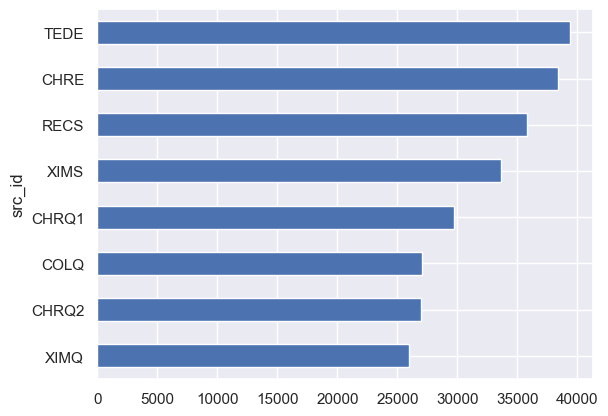

In [275]:
LIB.token_count.sort_values().plot.barh();

In [276]:
LIB['chunk_size'] = LIB.token_count // (CONFIG.chunk_factor - 1)

## Create CHUNK from TOKEN

In [277]:
TOKEN['chunk'] = TOKEN.join(LIB.chunk_size).apply(lambda x: x.name[1] / x.chunk_size, axis=1)
TOKEN['chunk'] = np.floor(TOKEN.chunk)
TOKEN['chunk'] = TOKEN.chunk.astype(int) + 1

In [278]:
CHUNK = TOKEN.groupby(['src_id', 'chunk'])\
    .token_str.apply(lambda x: ' '.join(map(str,x)))\
    .to_frame('chunk_str')

In [279]:
CHUNK['n_chars'] = CHUNK.chunk_str.str.len()

<Axes: xlabel='chunk'>

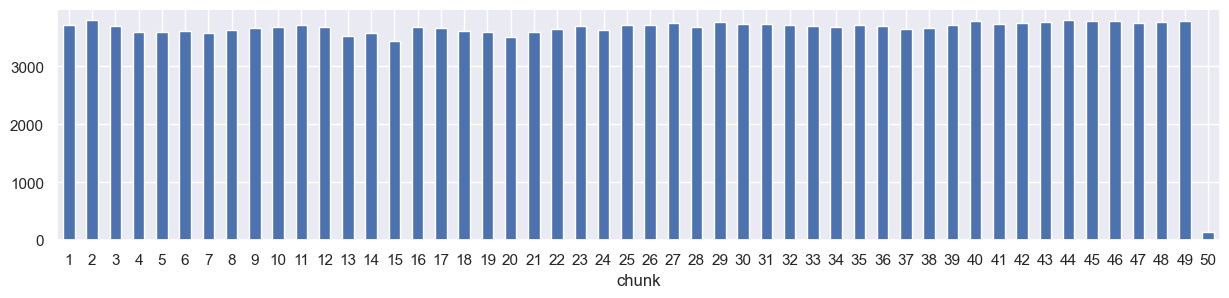

In [280]:
CHUNK.groupby('chunk').n_chars.mean().plot.bar(figsize=(15,3), rot=0)

# Generate Models

## From CTM to NMF 

In [328]:
G = CHUNK.groupby('src_id')
M = {k:{} for k in G.groups}
for key in G.groups:
    
    chunk = CHUNK.loc[key]

    # Create term count matrix CTM
    vectorizer = CountVectorizer(max_df=.9, token_pattern=CONFIG.token_pattern)
    CTM = pd.DataFrame(vectorizer.fit_transform(chunk.chunk_str).toarray(),
            columns=vectorizer.get_feature_names_out(), index=chunk.index)

    # Create VOCAB and computer residual IDF to find stop words
    N = len(CTM)
    VOCAB = CTM.sum().to_frame('n')
    VOCAB['p'] = VOCAB.n / VOCAB.n.sum()
    VOCAB['df'] = CTM.astype(bool).sum()
    VOCAB['idf_obs'] = np.log2((1 + N) / (1 + VOCAB.df)) + 1
    X_features = VOCAB[['n']]
    y_target = VOCAB.idf_obs
    reg = LinearRegression().fit(X_features, y_target)
    VOCAB['idf_exp'] = reg.predict(X_features)
    VOCAB['idf_res'] = VOCAB.idf_obs - VOCAB.idf_exp
    
    thresh = .75 # 1 #VOCAB.idf_res.quantile(.1)
    SIGS = VOCAB[VOCAB.idf_res < thresh].index.to_list()
    LIB.loc[key, 'n_sigs'] = len(SIGS)

    # Create reduced count matrix
    X = CTM[SIGS]
    
    # TFIDF
    tfidf_engine = TfidfTransformer(norm='l2', use_idf=True)
    TFIDF = pd.DataFrame(tfidf_engine.fit_transform(X).toarray(), 
                columns=SIGS, index=CTM.index)
    TFIDF_CORR = pd.DataFrame(TFIDF.T.corr(), index=TFIDF.index)
    TFIDF_CORR_Z = (TFIDF_CORR - TFIDF_CORR.mean()) / TFIDF_CORR.std()
    
    TFIDF_SIM = pd.DataFrame(cosine_similarity(TFIDF), index = TFIDF.index, columns=TFIDF.index)
    TFIDF_SIM_Z = (TFIDF_SIM - TFIDF_SIM.mean()) / TFIDF_SIM.std()

    # PCA
    pca_engine = PCA(5)
    pca = pd.DataFrame(pca_engine.fit_transform(TFIDF), index=TFIDF.index)
    PCA_SIM = pd.DataFrame(cosine_similarity(pca), index=pca.index, columns=pca.index)

    # NMF
    nmf_engine = NMF(n_components=CONFIG.n_topics, max_iter=2000, init='random')
    THETA = pd.DataFrame(nmf_engine.fit_transform(TFIDF), index=TFIDF.index)
    PHI = pd.DataFrame(nmf_engine.components_, columns=TFIDF.columns)
    TOPIC = PHI.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(CONFIG.n_topic_terms).index)).T.to_frame('top_terms')

    # chunk['top_topic'] = THETA.idxmax(1)
    CHUNK.loc[key, 'top_topic'] = THETA.idxmax(1)

    # Topic Salience
    PHIN = PHI + .01
    PW = PHIN.sum() / PHIN.sum().sum()
    PTw = (PHIN / PHIN.sum()).T
    PT = (PHIN.T.sum() / PHIN.T.sum().sum())
    PHI_DST = PTw * np.log(PTw/PT)
    PHI_SAL = PHI_DST.T * PW
    TOPIC['top_sal'] = PHI_SAL.T.apply(lambda x: ', '.join(x.sort_values(ascending=False)\
                                                           .head(CONFIG.n_topic_terms).index)).T
    TOPIC['ord'] = THETA[THETA > .1].idxmax().sort_values()
    
    λ = .5
    PHI_REL = λ * np.log(PHIN) + (1 - λ) * np.log(PHIN/PW)
    TOPIC['top_rel'] = PHI_REL.T.apply(lambda x: ', '.join(x.sort_values(ascending=False)\
                                                           .head(CONFIG.n_topic_terms).index)).T

    THETA_SIM = pd.DataFrame(cosine_similarity(THETA), index=THETA.index, columns=THETA.index)
    THETA_COR = THETA.T.corr()

    THETA_SIM_Z = (THETA_SIM - THETA_SIM.mean()) / THETA_SIM.std()
    THETA_COR_Z = (THETA_COR - THETA_COR.mean()) / THETA_COR.std()
    
    M[key] = {
        'CTM': CTM,
        'VOCAB': VOCAB,
        'TFIDF': TFIDF,
        'TFIDF_CORR': TFIDF_CORR,
        'TFIDF_CORR_Z': TFIDF_CORR_Z,
        'TFIDF_SIM': TFIDF_SIM,
        'TFIDF_SIM_Z': TFIDF_SIM_Z,
        'PCA': pca,
        'PCA_SIM': PCA_SIM,
        'THETA': THETA,
        'PHI': PHI,
        'TOPIC': TOPIC,
        'THETA_SIM': THETA_SIM,
        'THETA_SIM_Z': THETA_SIM_Z,
        'THETA_COR': THETA_COR,
        'THETA_COR_Z': THETA_COR_Z
    }
    # LIB.loc[key, 'model_coherence'] = round(coherence_score, 2)

## Linkage Matrix

Can also get this from Seaborn's clustermap. 

In [329]:
from scipy.cluster.hierarchy import linkage, cophenet, fcluster
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score

def relabel_by_first_appearance(labels):
    label_map = {}
    new_labels = []
    next_label = 0

    for label in labels:
        if label not in label_map:
            label_map[label] = next_label
            next_label += 1
        new_labels.append(label_map[label])
    
    return np.array(new_labels)

def get_linkage_matrix(source, model='TFIDF', n_clusters=5, normalize=False):
    
    X = M[source][model]
    if normalize:
        X = normalize(X.values, norm='l2')
    
    # SIMS
    dist_matrix = pdist(X.values, metric='euclidean')        
    M[source]['dist_matrix'] = dist_matrix

    # TREE
    linkage_matrix = linkage(dist_matrix, method='ward')
    M[source]['linkage_matrix'] = linkage_matrix

    # LABELS
    labels = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')
    labels = relabel_by_first_appearance(labels)
    # labels = [f"L{int(label)}" for label in labels]
    M[source]['label'] = labels
    CHUNK.loc[source, 'label'] = labels
    
    # Cophenetic score
    coph_corr, _ = cophenet(linkage_matrix, dist_matrix)
    LIB.loc[source, 'coph_corr'] = coph_corr
    
    # Flat clusters for silhouette
    sil_score = silhouette_score(X.values, labels)
    LIB.loc[source, 'sil_score'] = sil_score
    
    # plot_grid(CHUNK.loc[source, 'label'].unstack(fill_value=''))

# Visualizations

In [331]:
def plot_topics_over_time(source, thresh=.0):
    
    TOPIC = M[source]['TOPIC'] 
    THETA = M[source]['THETA'] 
    
    x_axis_labels = [idx for idx in THETA.index.to_list()]
    legend = [f"T{i}: {t}" for i, t in enumerate(TOPIC.top_terms.to_list())]
    y_axis_labels = [f"T{i}" for i, t in enumerate(TOPIC.top_terms.to_list())]
    title = LIB.loc[source].title
    
    fig = px.imshow(THETA[THETA >= thresh].T, 
        x = x_axis_labels,
        y = y_axis_labels,
        color_continuous_scale=px.colors.sequential.Greens, 
        height=300, width=1200, aspect='auto', 
        title=title)
    
    fig.update_layout(
        xaxis_title="Chunk ID",
        yaxis_title="Topic Gloss",
        xaxis={ 'tickangle': 45},
        yaxis={ 'tickangle': 0}
    )
    
    print()
    print("\n".join(legend))
    fig.show()

In [332]:
def plot_dendrogram(source):
    Z = M[source]['linkage_matrix']
    dg_labels = M[source]['THETA'].index.to_list()
    plt.figure()
    plt.subplots(figsize=(12,2))
    dendrogram(Z, leaf_rotation=90, leaf_font_size=8, labels=dg_labels)
    plt.title(LIB.loc[source].title)
    plt.xlabel('Chunk ID')
    plt.ylabel('Distance')
    plt.show()    

In [333]:
def plot_cluster_over_time(source, model, img_config):
    X = M[source][model]
    title = LIB.loc[source].title + f" ({model})"
    sns.clustermap(X, **img_config).fig.suptitle(title)
    plt.show()

# Plot All

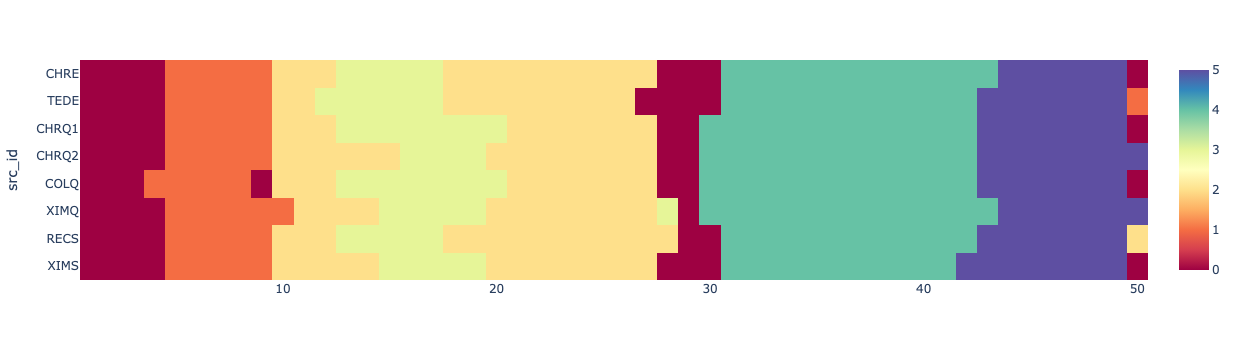

In [371]:
for source in M.keys():
    get_linkage_matrix(source, 'TFIDF_SIM_Z', n_clusters=6)
all_labels = CHUNK.label.unstack().join(LIB.lang).sort_values('lang').iloc[:,:-1]
px.imshow(all_labels, color_continuous_scale=px.colors.colorbrewer.Spectral)

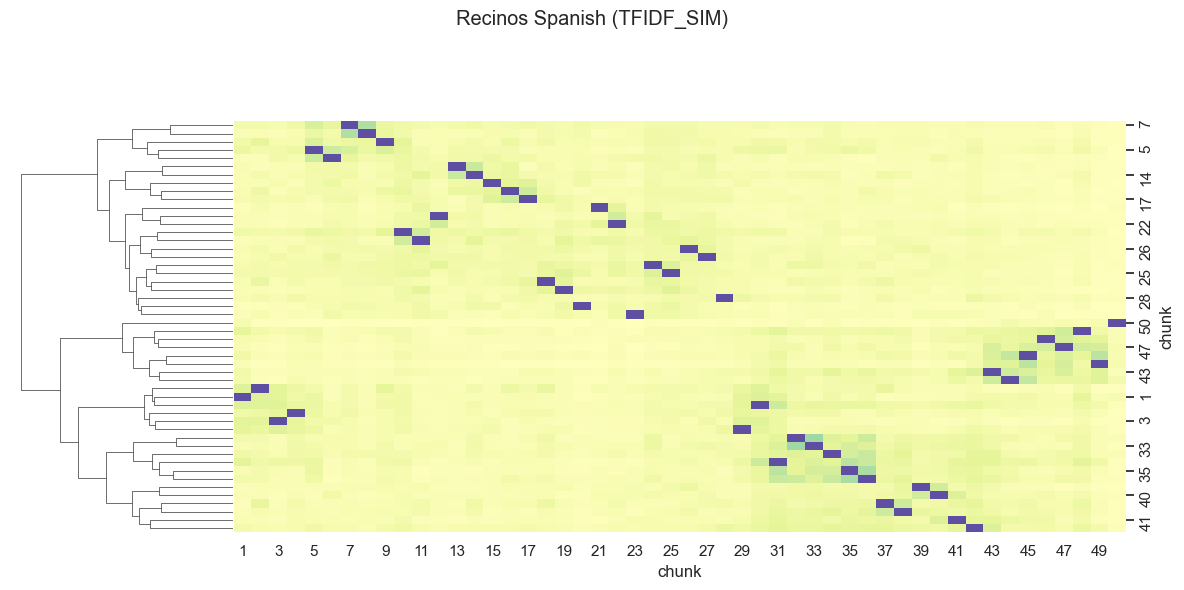


T0: dios, sol, quitzé, acab, fuego
T1: hun, pelota, mensajeros, ixbalanqué, árbol
T2: zipacná, caquix, cuatrocientos, cabracán, cangrejo
T3: cielo, tierra, formador, hombre, creador
T4: ahpop, ahau, quiché, rey, ciudad
T5: doncellas, avilix, hacavitz, mahucutah, quitzé


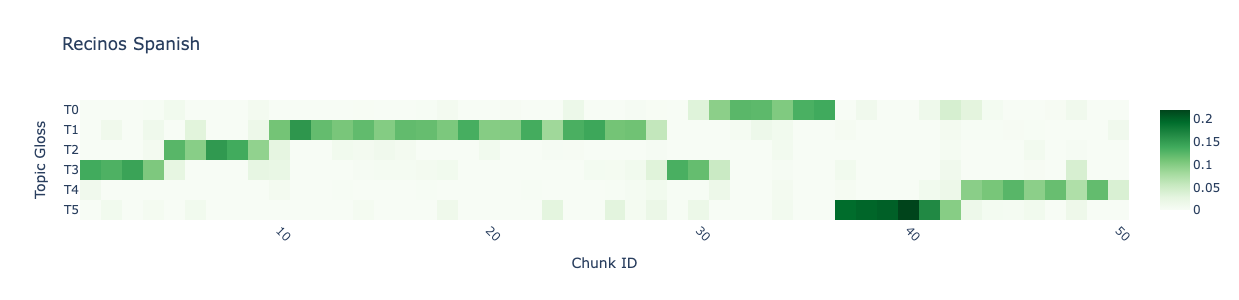

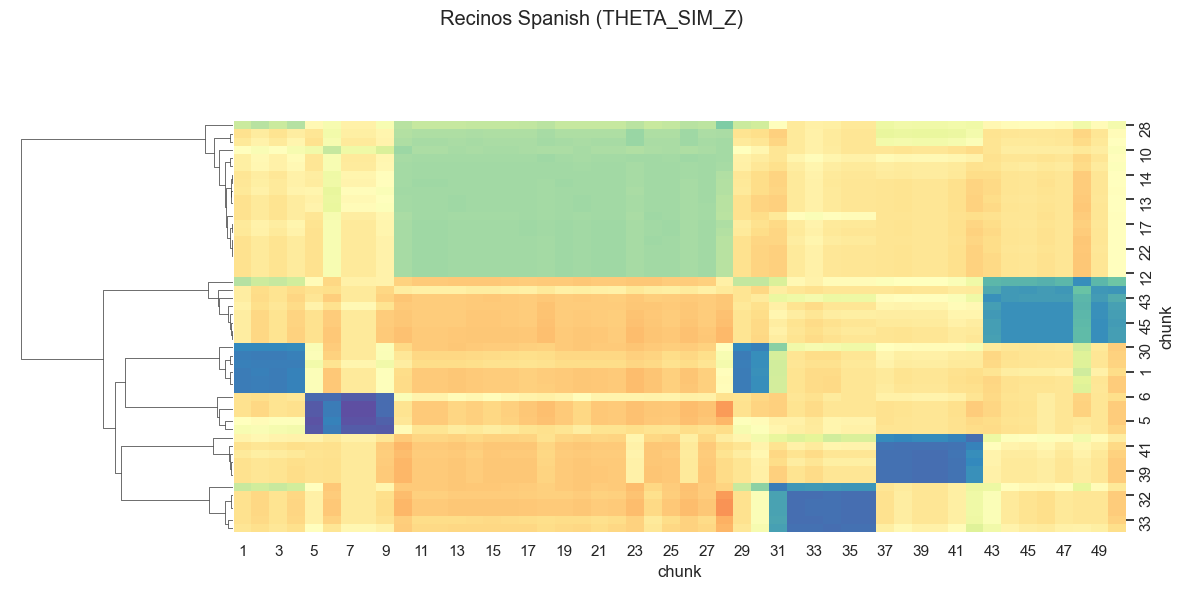

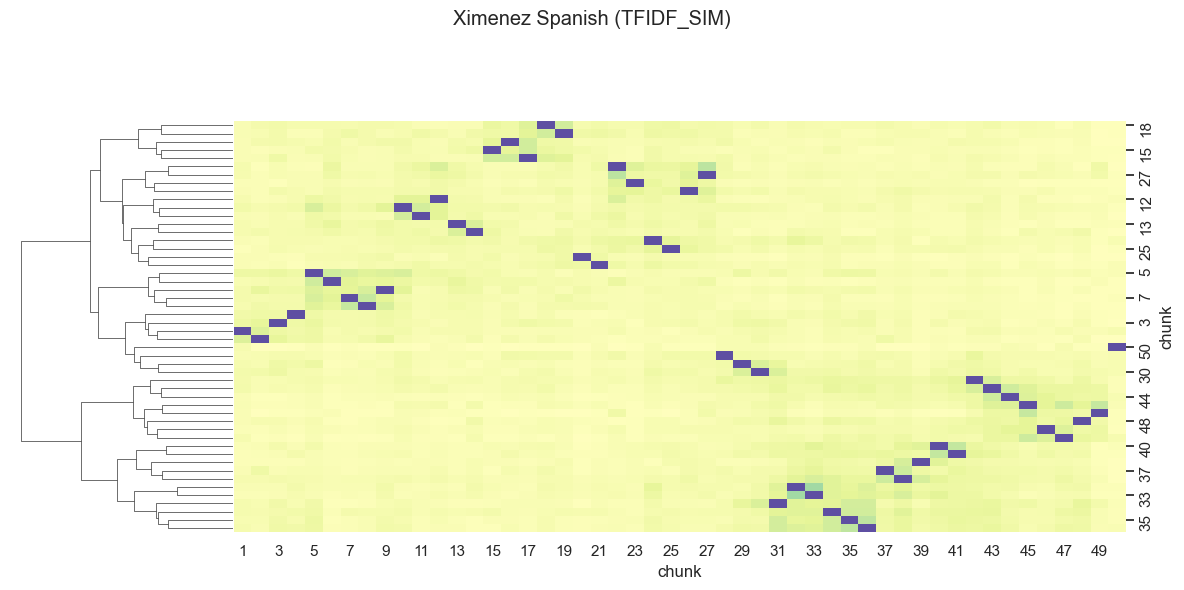


T0: tohíl, donçellas, mahucutah, tabanos, hacauítz
T1: muchachos, zípacna, entonzes, vvcub, dixo
T2: sses, ahau, rey, generaçíon, casas
T3: ínfíerno, came, díxo, señor, sor
T4: ídolo, sol, tohíl, fuego, mahucutah
T5: todo, tierra, çíelo, zielo, qoquando


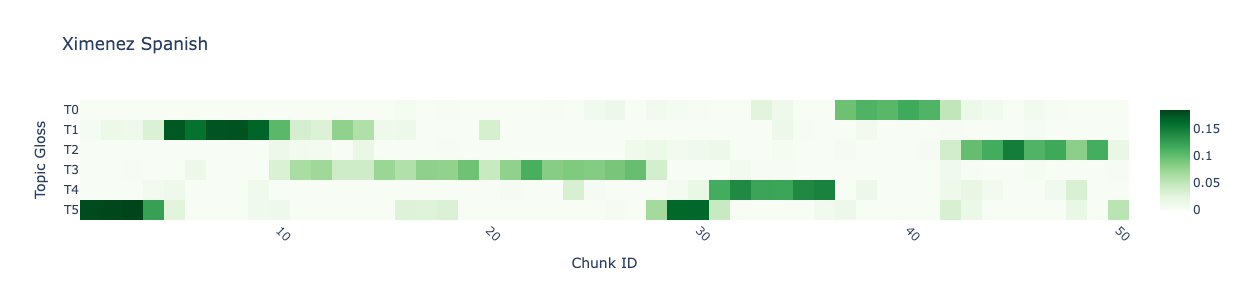

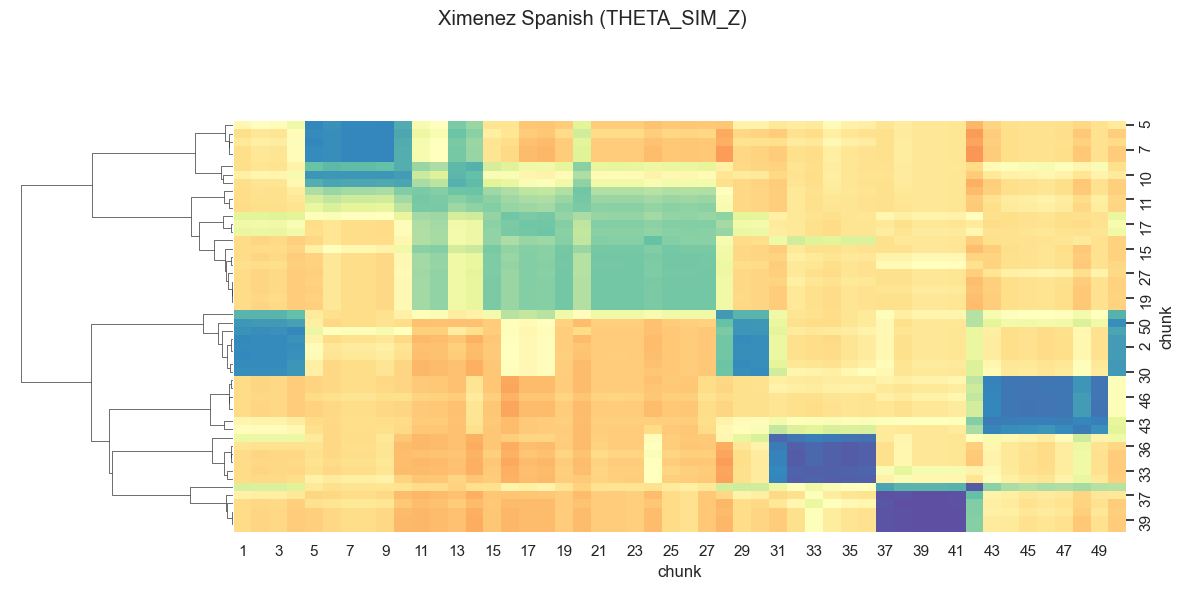

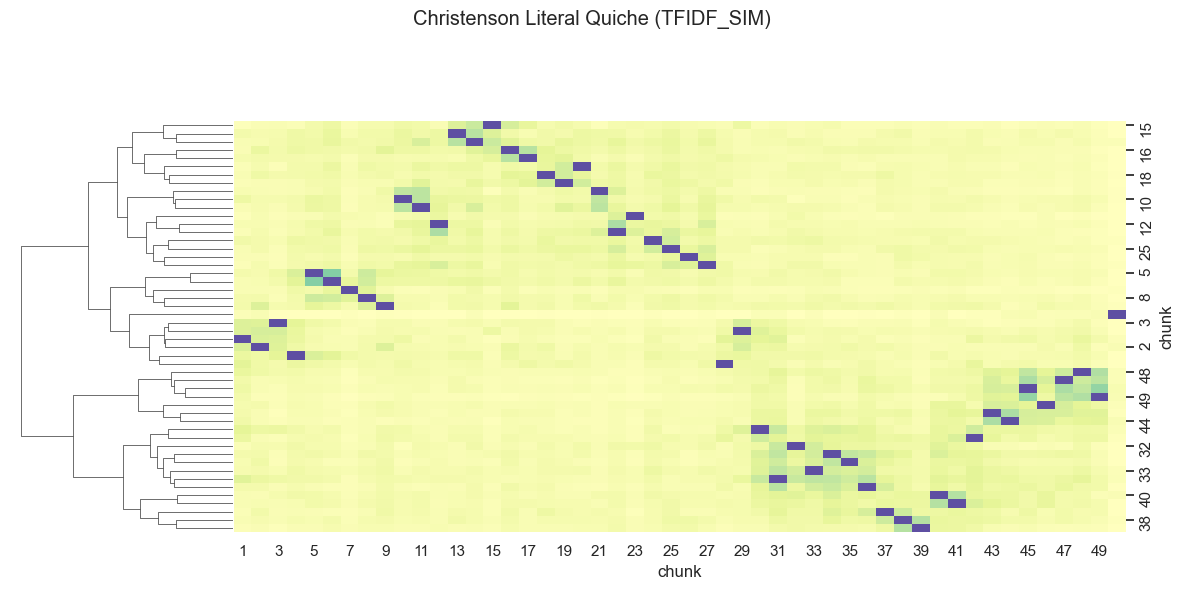


T0: k'ab'awil, kitze, majukutaj, chila, ik'i
T1: kaj, b'it, tz'aq, ulew, k'ajolom
T2: q'apojib, k'ul, awilix, jaq'awitz, kaib
T3: pop, k'iche, le, tinamit, k'am
T4: kaqix, sipakna, wuqub, jul, nu
T5: kame, kik, b'a, samajel, naqi


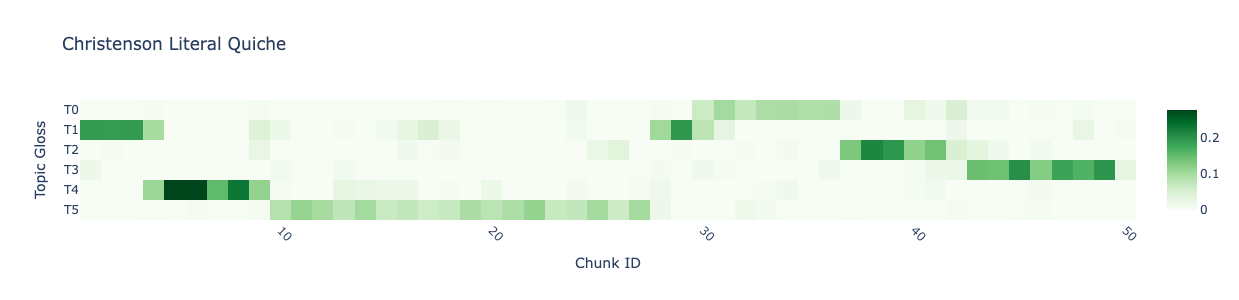

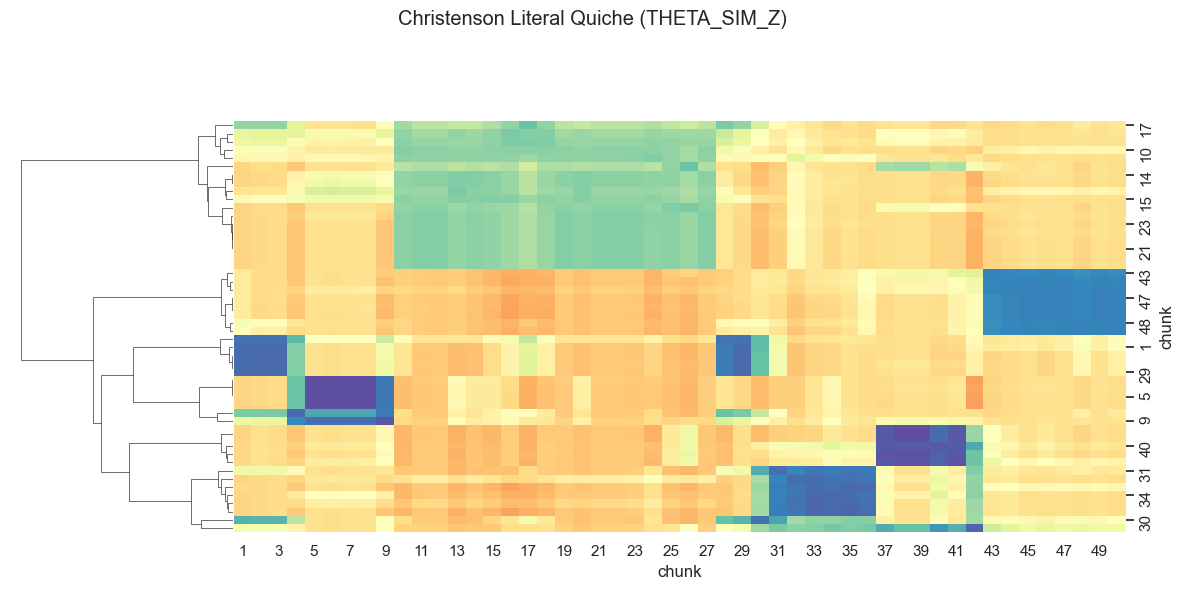

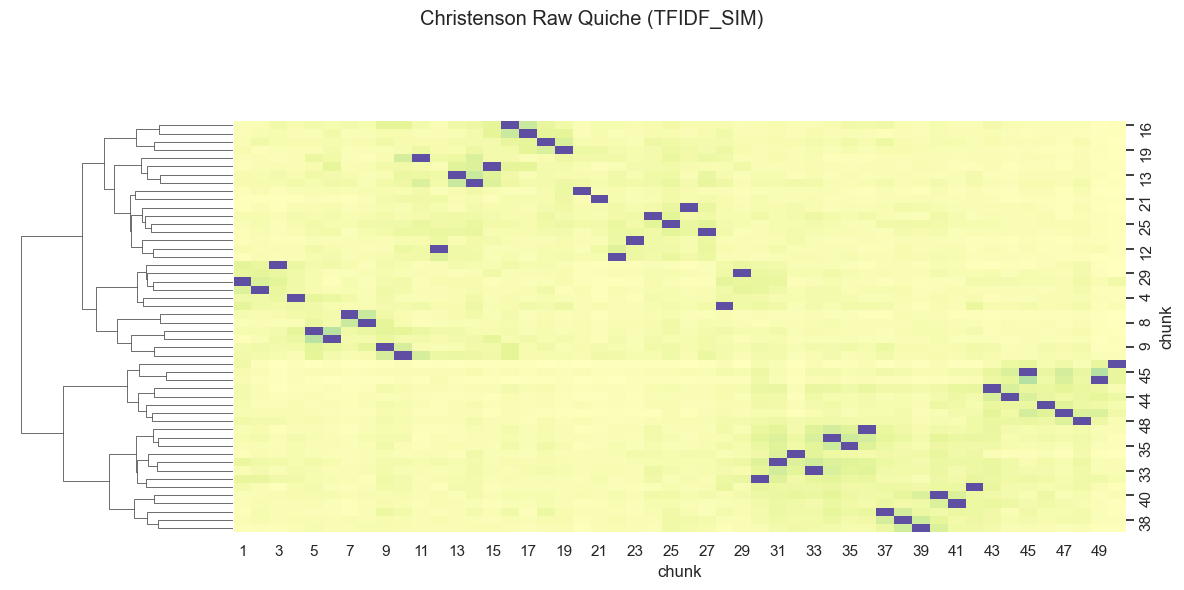


T0: quitze, tinamit, mahucutah, acab, hacavitz
T1: zipacna, omuch, hul, tap, cabal
T2: cah, bit, alom, qaholom, tzacol
T3: caquix, vvcub, mama, lal, cabracan
T4: catit, ixcatit, atit, batz, cho
T5: came, vvcub, quic, capoh, vholom


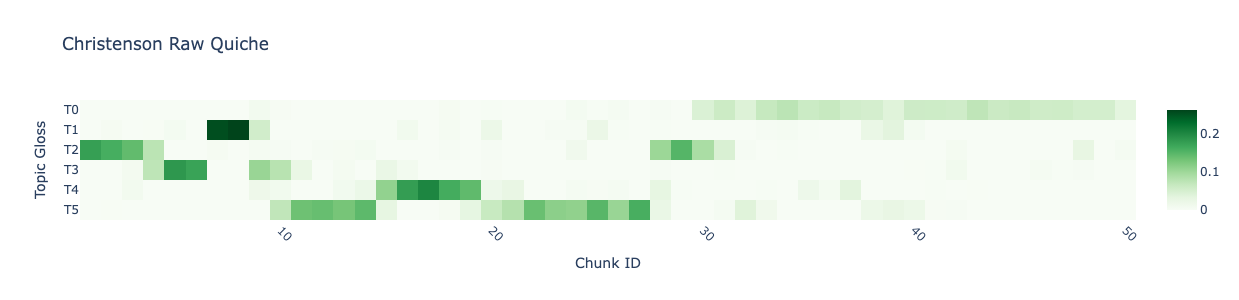

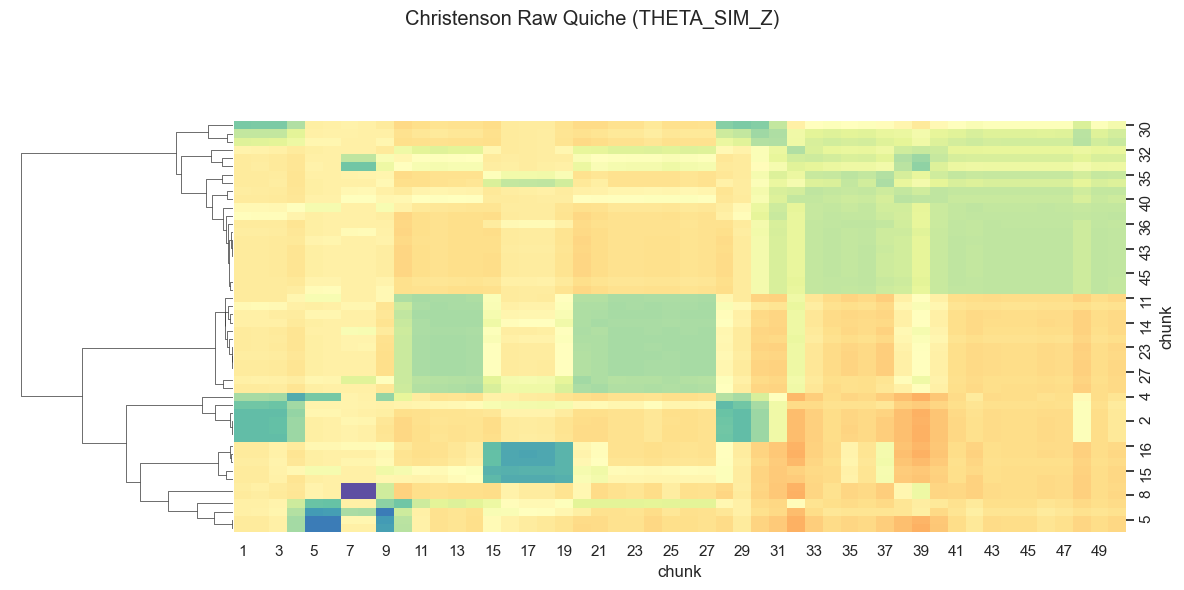

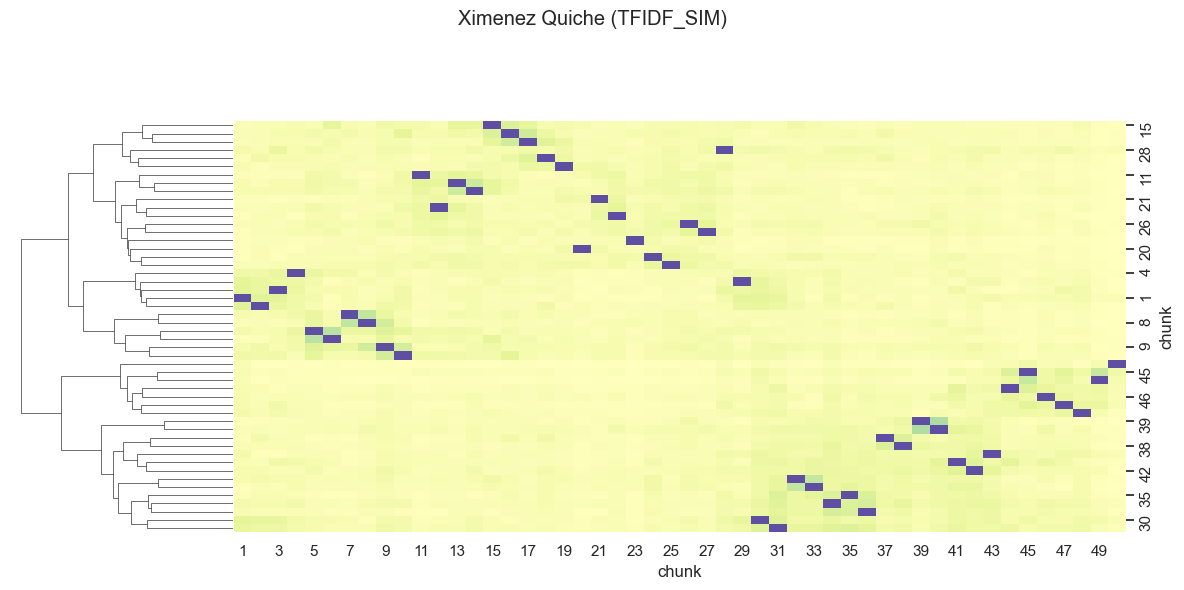


T0: quitze, mahucutah, acab, hacavitz, iqui
T1: came, vvcub, capoh, quic, vholom
T2: cah, bit, ah, alom, qaholom
T3: zipacna, caquix, vvcub, omuch, hul
T4: quiche, ahpop, tinamit, chinamit, vnim
T5: atit, catit, batz, ixcatit, chouen


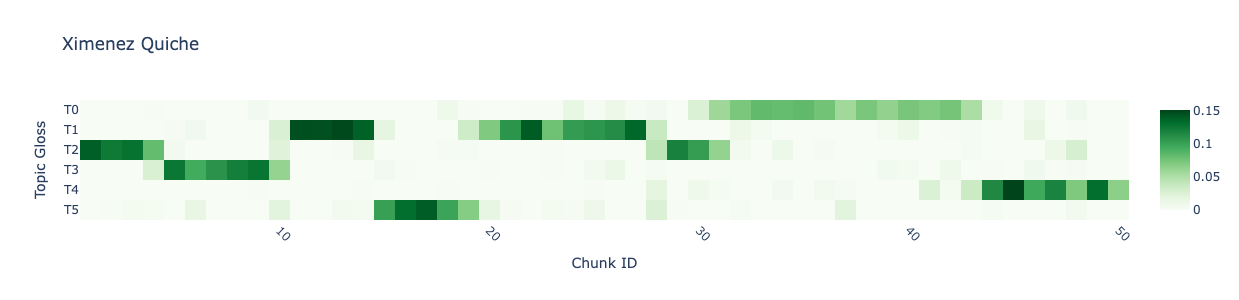

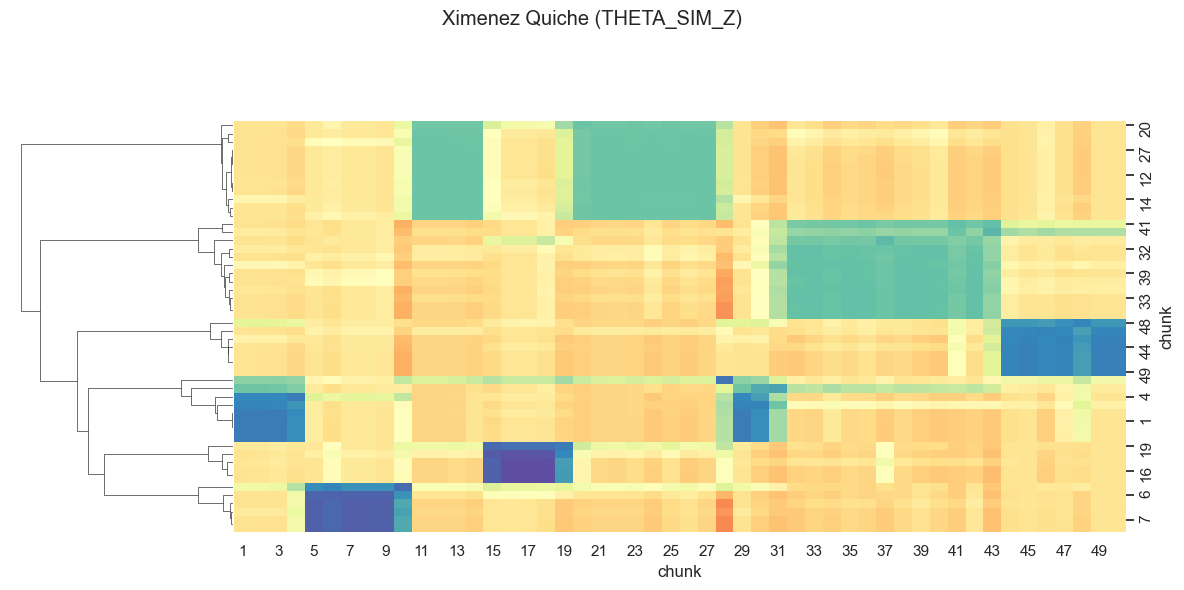

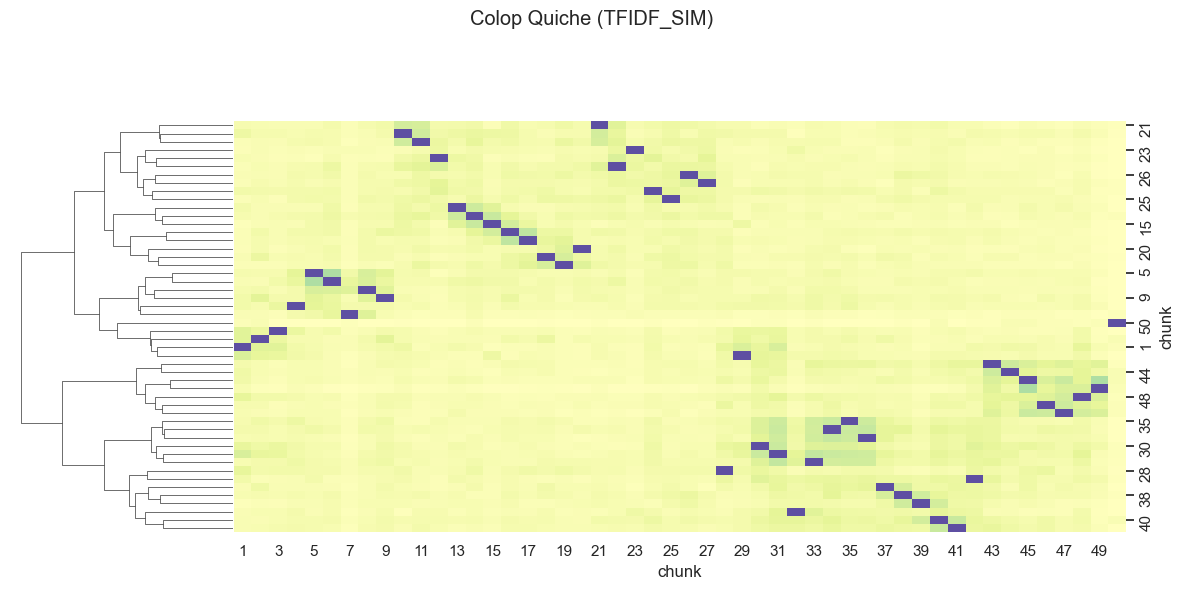


T0: kak'ix, sipakna, kab'raqan, omuch, jul
T1: q'ij, chila, kaj, kitze, releb'al
T2: kati't, ati't, b'atz, chowen, qati't
T3: kame, naki, ajal, b'a, q'ala
T4: q'apojib, kitze, majukutaj, jakawitz, awilix
T5: ajpop, k'iche, q'amja, unim, q'alel


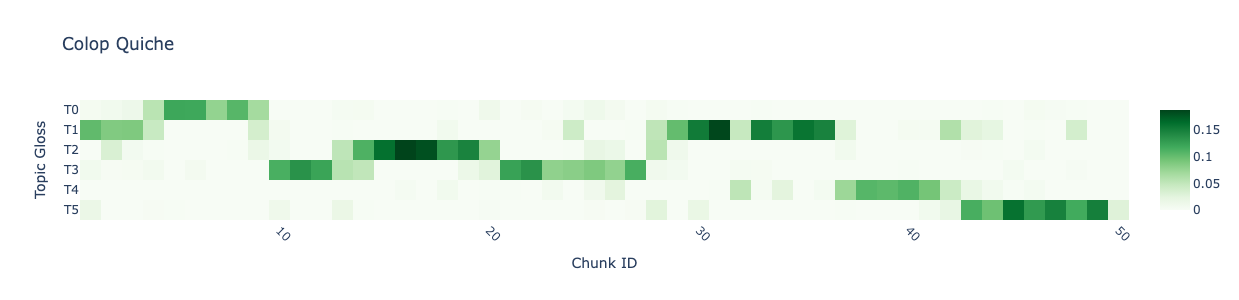

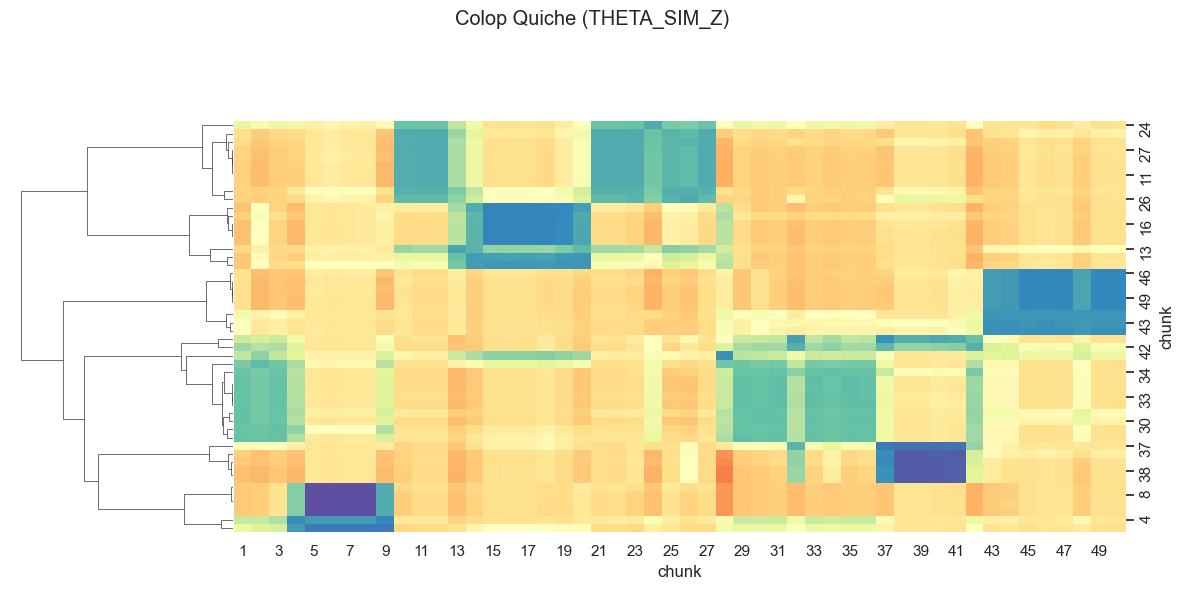

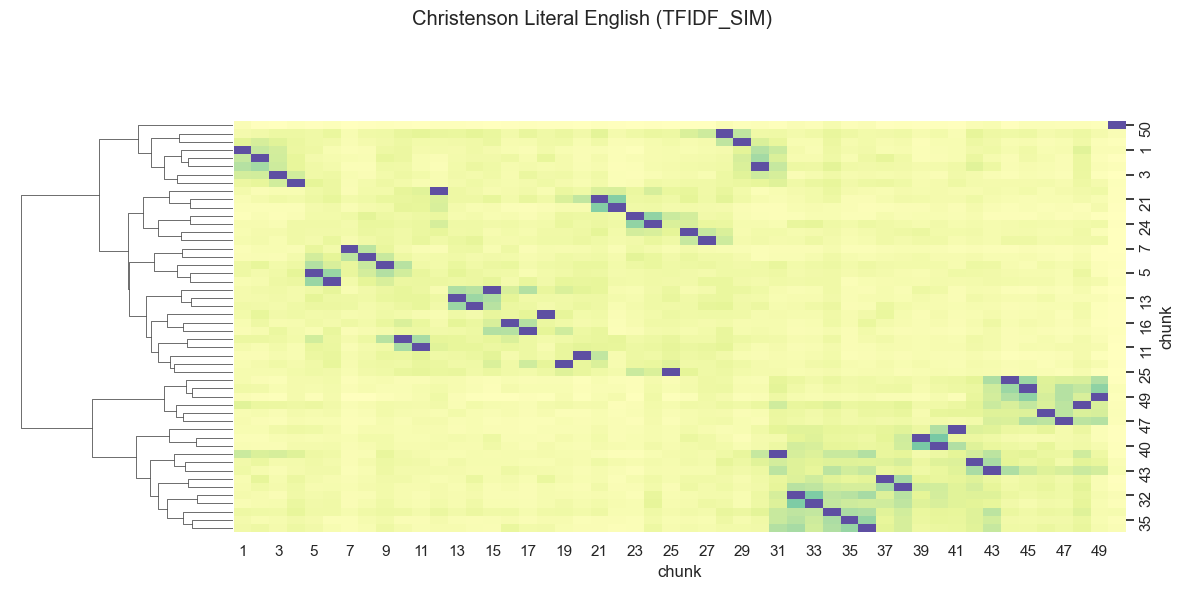


T0: maidens, lady, painted, nations, robes
T1: hunahpu, grandmother, boys, death, i
T2: sky, has, who, earth, framer
T3: lord, ah, house, pop, co
T4: sun, name, god, quitze, coming
T5: tohil, nations, fire, auilix, before


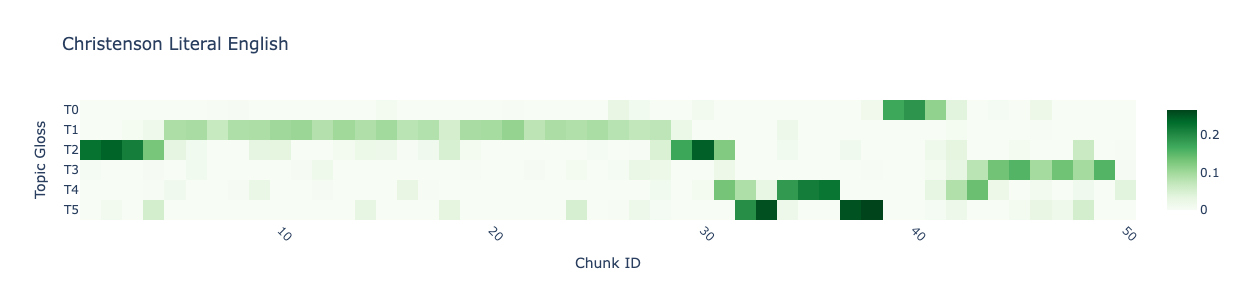

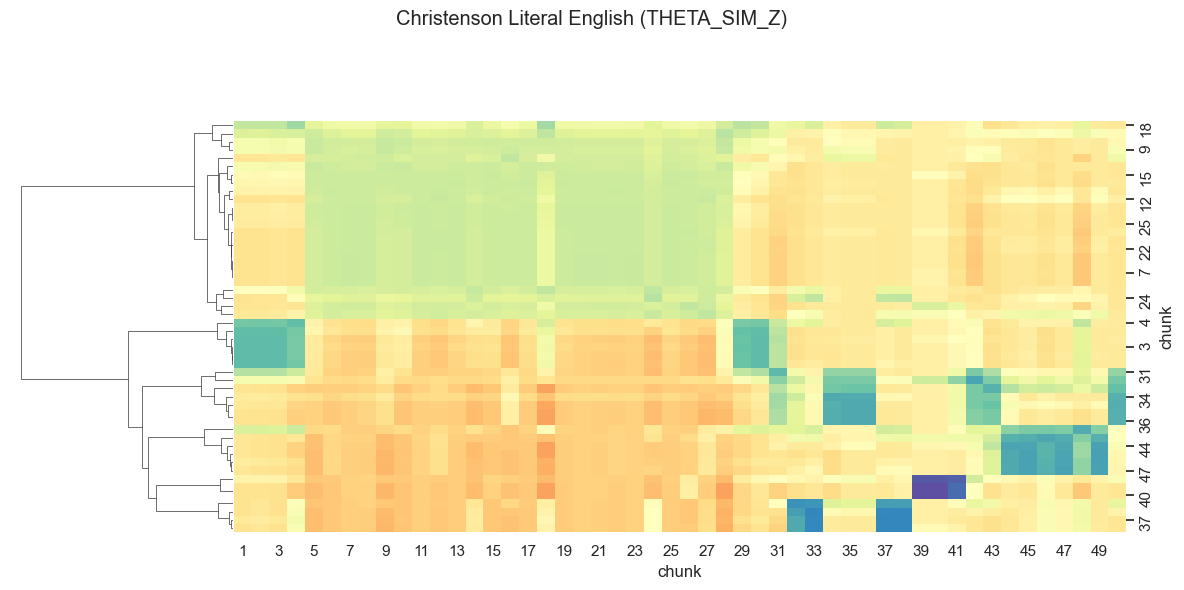

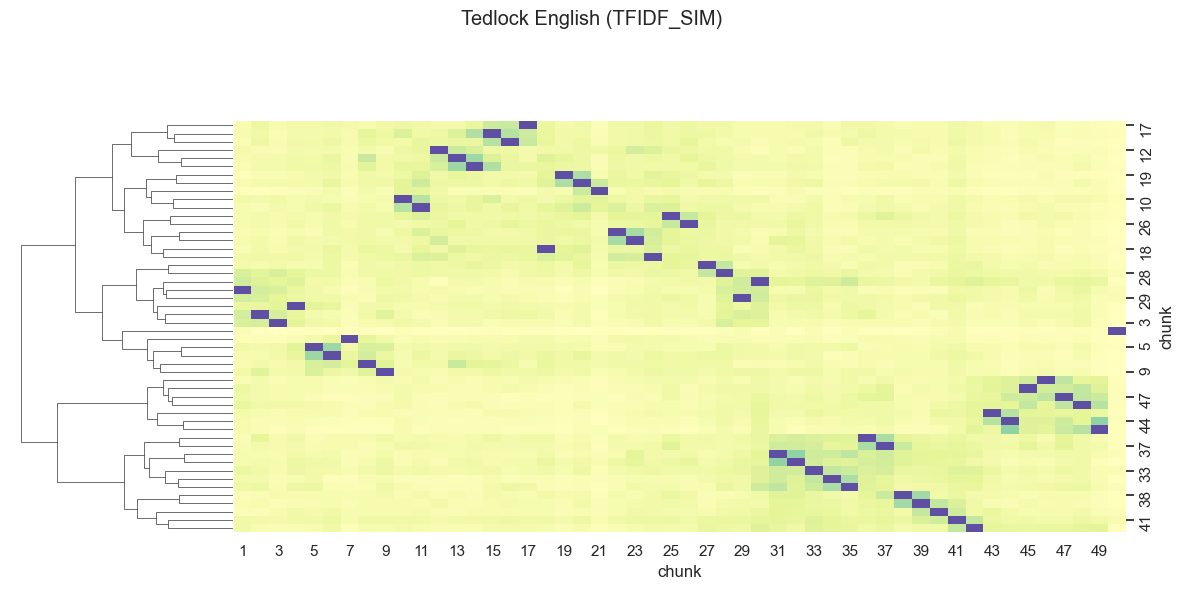


T0: tohil, quitze, mahucutah, night, god
T1: xibalba, ball, death, xibalbans, flowers
T2: her, she, maiden, macaw, tree
T3: sky, earth, human, heart, maker
T4: concerning, santa, cruz, completed, everything
T5: keeper, mat, generation, houses, reception


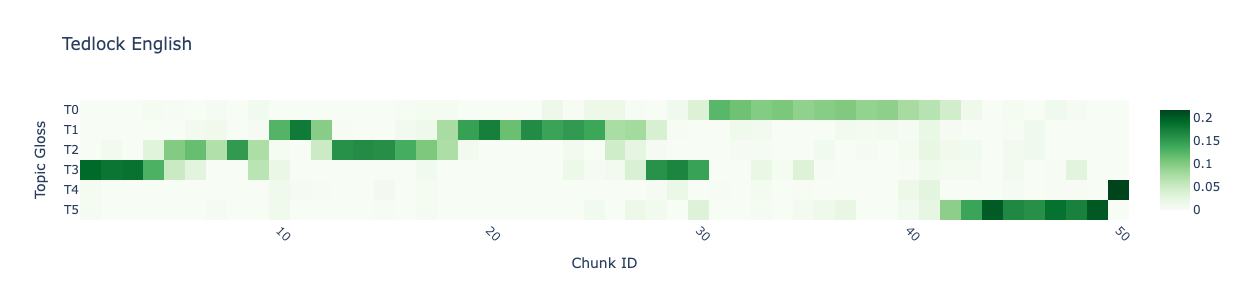

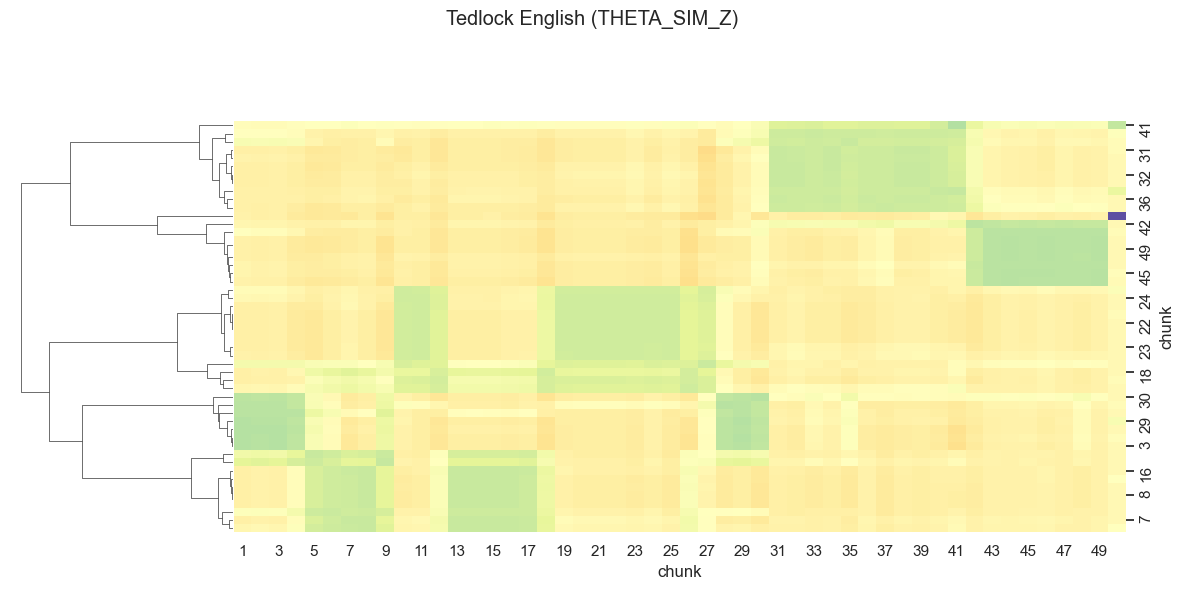

In [372]:
h = 6
w = 6

img_config = dict( 
    cmap='Spectral',
    method='ward',
    metric='euclidean',
    center=0,
    z_score=None,
    cbar_pos=None,
    figsize=(w*2,h),
    col_cluster=False
)

for source in LIB.sort_values(['lang'], ascending=False).index:

    plot_cluster_over_time(source, 'TFIDF_SIM', img_config)
    plot_topics_over_time(source)
    plot_cluster_over_time(source, 'THETA_SIM_Z', img_config)

# Conclusions

- There appear to be 2 major parts, each containing 3 subparts
- The subparts are of two types: introductory and substantive
- The introductory parts echo each other
- Spanish translations are noisier

# Save

In [336]:
import pickle

CHUNK.to_pickle('CHUNK.pickle')
with open("M.pickle", "wb") as file:
    pickle.dump(M, file)